# Week 3 — EyePACS / EyeQ data preparation

Extracts the EyeQ-labelled subset from the competition archives and
writes it preprocessed to `/kaggle/working/eyeq_512`.

## Config

In [1]:
import os, io, glob, bisect, zipfile
from itertools import accumulate

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

BASE   = "/kaggle/input/competitions/diabetic-retinopathy-detection"
WORK   = "/kaggle/working"
OUT    = f"{WORK}/eyeq_512"
EYEQ   = f"{WORK}/EyeQ"

TARGET = 512      # px; below ~448 the blur signal starts to disappear
LIMIT  = None     # cap image count for testing; None = all

os.makedirs(OUT, exist_ok=True)

## Archive inventory

In [2]:
for f in sorted(os.listdir(BASE)):
    print(f"{f:26s} {os.path.getsize(f'{BASE}/{f}') / 1e9:7.2f} GB")

sample.zip                    0.01 GB
sampleSubmission.csv.zip      0.00 GB
test.zip.001                  8.39 GB
test.zip.002                  8.39 GB
test.zip.003                  8.39 GB
test.zip.004                  8.39 GB
test.zip.005                  8.39 GB
test.zip.006                  8.39 GB
test.zip.007                  2.96 GB
train.zip.001                 8.39 GB
train.zip.002                 8.39 GB
train.zip.003                 8.39 GB
train.zip.004                 8.39 GB
train.zip.005                 1.43 GB
trainLabels.csv.zip           0.00 GB


In [3]:
!df -h /kaggle/working

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  148K   20G   1% /kaggle/working


## Sample images

10 files
shape: (3168, 4752, 3)


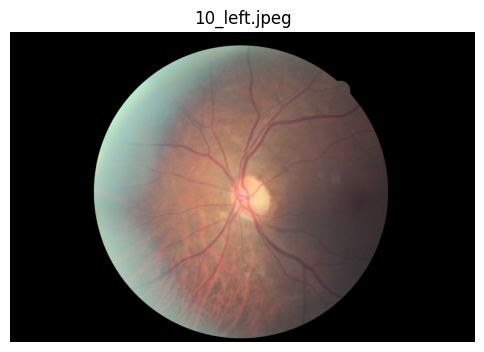

In [4]:
with zipfile.ZipFile(f"{BASE}/sample.zip") as z:
    z.extractall(f"{WORK}/sample")

sample_files = sorted(glob.glob(f"{WORK}/sample/**/*.jpeg", recursive=True))
print(len(sample_files), "files")

img = cv2.cvtColor(cv2.imread(sample_files[0]), cv2.COLOR_BGR2RGB)
print("shape:", img.shape)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(os.path.basename(sample_files[0]))
plt.show()

## Competition labels

In [5]:
with zipfile.ZipFile(f"{BASE}/trainLabels.csv.zip") as z:
    with z.open(z.namelist()[0]) as f:
        labels = pd.read_csv(f)

# "10_left" / "10_right" are the two eyes of one patient
labels["patient_id"] = labels["image"].str.split("_").str[0]
labels["eye"]        = labels["image"].str.split("_").str[1]

print(labels.shape)
print("patients:", labels.patient_id.nunique())
print(labels.level.value_counts().sort_index())
labels.head()

(35126, 4)
patients: 17563
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


,image,level,patient_id,eye
0,10_left,0,10,left
1,10_right,0,10,right
2,13_left,0,13,left
3,13_right,0,13,right
4,15_left,1,15,left


## Split archive reader

`train.zip` is delivered as five byte-split parts totalling ~35 GB.
`/kaggle/working` caps at 20 GB, so the parts are never joined on disk.

In [6]:
class SplitZipStream(io.RawIOBase):
    """Present train.zip.001..005 as one seekable stream."""

    def __init__(self, parts):
        self.parts  = sorted(parts)
        self.fhs    = [open(p, "rb") for p in self.parts]
        self.sizes  = [os.path.getsize(p) for p in self.parts]
        self.starts = [0] + list(accumulate(self.sizes))
        self.total  = self.starts[-1]
        self.pos    = 0

    def readable(self): return True
    def seekable(self): return True
    def tell(self):     return self.pos

    def seek(self, offset, whence=io.SEEK_SET):
        if   whence == io.SEEK_SET: self.pos = offset
        elif whence == io.SEEK_CUR: self.pos += offset
        elif whence == io.SEEK_END: self.pos = self.total + offset
        self.pos = max(0, min(self.pos, self.total))
        return self.pos

    def readinto(self, buf):
        want, got = len(buf), 0
        while got < want and self.pos < self.total:
            i     = bisect.bisect_right(self.starts, self.pos) - 1
            local = self.pos - self.starts[i]
            self.fhs[i].seek(local)
            chunk = self.fhs[i].read(min(want - got, self.sizes[i] - local))
            if not chunk:
                break
            buf[got:got + len(chunk)] = chunk
            got      += len(chunk)
            self.pos += len(chunk)
        return got

    def close(self):
        for f in self.fhs:
            f.close()
        super().close()


def open_split(pattern):
    parts = sorted(glob.glob(pattern))
    assert parts, f"no parts matched {pattern}"
    stream = io.BufferedReader(SplitZipStream(parts), buffer_size=1 << 22)
    return zipfile.ZipFile(stream)

In [7]:
# reading the central directory of a 35 GB stream takes ~1 min
zf      = open_split(f"{BASE}/train.zip.0*")
members = [n for n in zf.namelist() if n.lower().endswith(".jpeg")]

print(len(members), "images")
print(members[0])

35126 images
train/10003_left.jpeg


## EyeQ quality labels

`quality`: 0 = Good, 1 = Usable, 2 = Reject.

In [8]:
if not os.path.isdir(EYEQ):
    !git clone -q https://github.com/HzFu/EyeQ.git {EYEQ}

eyeq = pd.concat([
    pd.read_csv(f"{EYEQ}/data/Label_EyeQ_train.csv"),
    pd.read_csv(f"{EYEQ}/data/Label_EyeQ_test.csv"),
], ignore_index=True)

print(eyeq.shape, eyeq.columns.tolist())
eyeq.head()

(28792, 4) ['Unnamed: 0', 'image', 'quality', 'DR_grade']


,Unnamed: 0,image,quality,DR_grade
0,0,10009_left.jpeg,0,0
1,1,10009_right.jpeg,0,0
2,2,10014_left.jpeg,2,0
3,3,10014_right.jpeg,2,0
4,4,10015_left.jpeg,0,0


In [9]:
# EyeQ names carry ".jpeg", archive members carry a "train/" prefix
def stem(s):
    return os.path.splitext(os.path.basename(str(s)))[0]

eyeq["stem"]   = eyeq["image"].map(stem)
eyeq["member"] = eyeq["stem"].map({stem(m): m for m in members})

matched = eyeq.dropna(subset=["member"]).reset_index(drop=True)

# the remainder sit in test.zip — EyeQ keeps the EyePACS partition
print(f"matched {len(matched)} / {len(eyeq)}")
print(matched["quality"].value_counts().sort_index())

matched 12543 / 28792
quality
0    8347
1    1876
2    2320
Name: count, dtype: int64


## Preprocess

In [10]:
def crop_fov(img, tol=7):
    """Trim the black surround around the circular field of view."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > tol
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    return img[ys.min():ys.max() + 1, xs.min():xs.max() + 1]


def pad_square(img):
    """Pad the short side so the resize does not distort the disc."""
    h, w = img.shape[:2]
    s    = max(h, w)
    t, l = (s - h) // 2, (s - w) // 2
    return cv2.copyMakeBorder(img, t, s - h - t, l, s - w - l,
                              cv2.BORDER_CONSTANT, value=[0, 0, 0])


def convert(member, dest):
    with zf.open(member) as f:
        buf = np.frombuffer(f.read(), np.uint8)
    img = cv2.imdecode(buf, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("decode failed")
    img = cv2.resize(pad_square(crop_fov(img)), (TARGET, TARGET),
                     interpolation=cv2.INTER_AREA)
    cv2.imwrite(dest, img)

In [11]:
todo = matched["member"].tolist()
if LIMIT:
    todo = todo[:LIMIT]
assert todo, "nothing to extract"

# sequential read order — random access across five parts is much slower
infos  = sorted((zf.getinfo(m) for m in todo), key=lambda i: i.header_offset)
failed = []

for info in tqdm(infos):
    dest = f"{OUT}/{stem(info.filename)}.png"
    if os.path.exists(dest):
        continue
    try:
        convert(info, dest)
    except Exception as e:
        failed.append((info.filename, str(e)))

print(len(os.listdir(OUT)), "written ·", len(failed), "failed")

pd.DataFrame(failed, columns=["file", "error"]).to_csv(
    f"{WORK}/failed_images.csv", index=False)

  0%|          | 0/12543 [00:00<?, ?it/s]

12543 written · 0 failed


In [12]:
!du -sh {OUT}

3.0G	/kaggle/working/eyeq_512


## Manifest

In [13]:
manifest = matched[["stem", "image", "quality", "DR_grade"]].copy()
manifest["path"]       = manifest["stem"].map(lambda s: f"{OUT}/{s}.png")
manifest["patient_id"] = manifest["stem"].str.split("_").str[0]
manifest["eye"]        = manifest["stem"].str.split("_").str[1]
manifest               = manifest[manifest.path.map(os.path.exists)]

manifest.to_csv(f"{WORK}/manifest_eyeq_512.csv", index=False)

print(manifest.shape)
print("patients:", manifest.patient_id.nunique())
manifest.head()

(12543, 7)
patients: 8614


,stem,image,quality,DR_grade,path,patient_id,eye
0,10009_left,10009_left.jpeg,0,0,/kaggle/working/eyeq_512/10009_left.png,10009,left
1,10009_right,10009_right.jpeg,0,0,/kaggle/working/eyeq_512/10009_right.png,10009,right
2,10014_left,10014_left.jpeg,2,0,/kaggle/working/eyeq_512/10014_left.png,10014,left
3,10014_right,10014_right.jpeg,2,0,/kaggle/working/eyeq_512/10014_right.png,10014,right
4,10015_left,10015_left.jpeg,0,0,/kaggle/working/eyeq_512/10015_left.png,10015,left


## Check

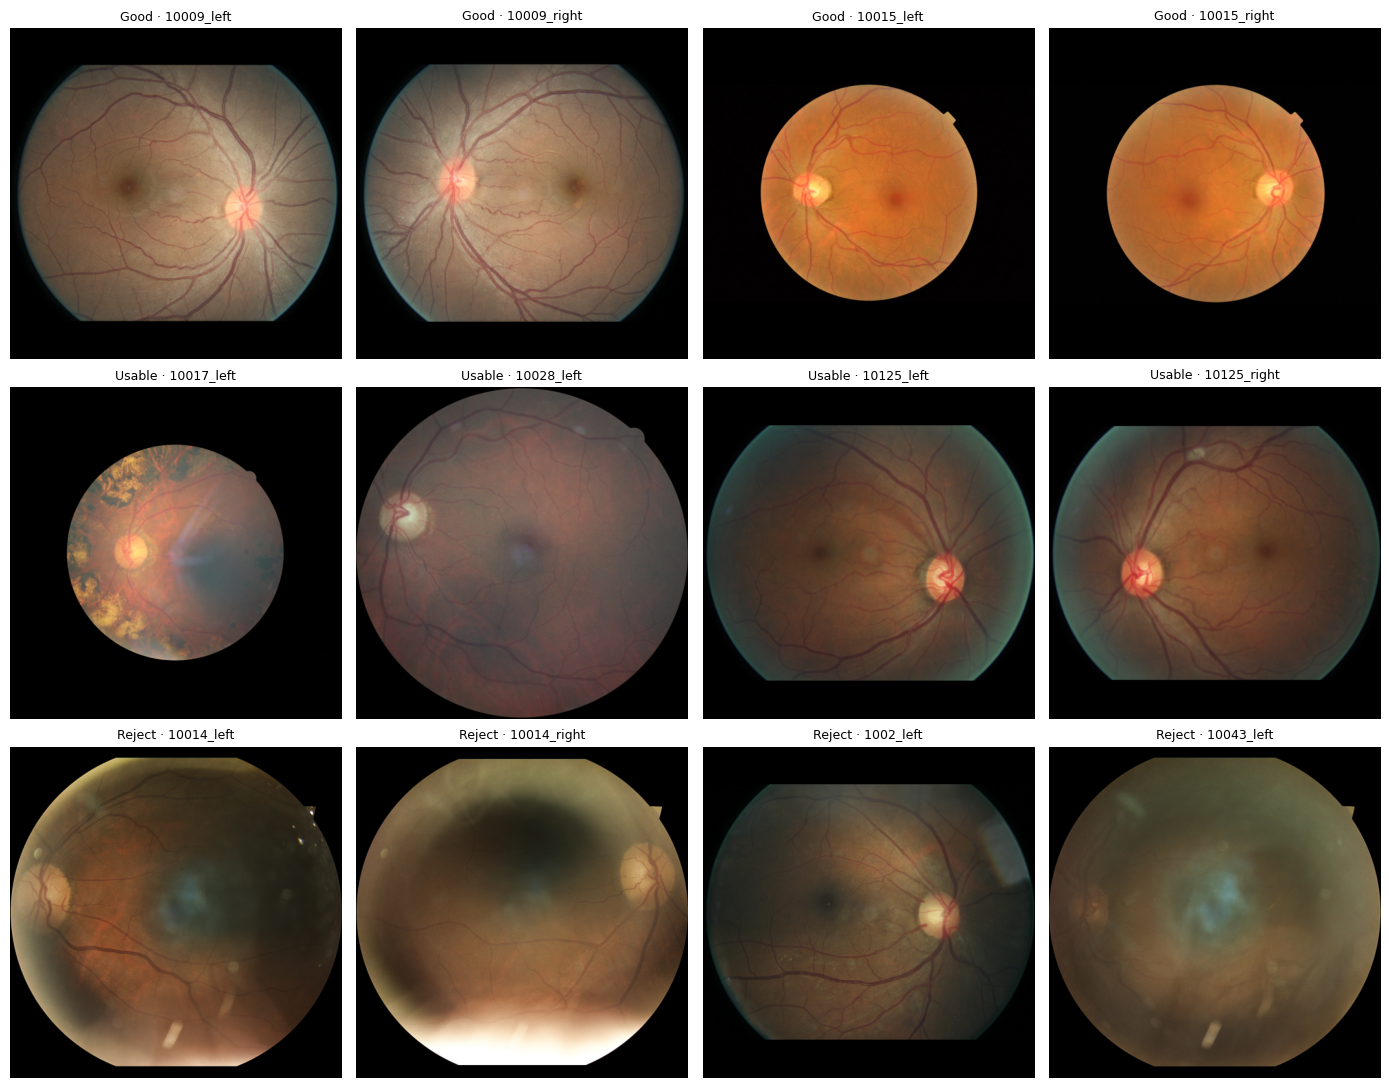

In [14]:
NAMES = {0: "Good", 1: "Usable", 2: "Reject"}

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax in axes.ravel():
    ax.axis("off")

for row, q in enumerate([0, 1, 2]):
    subset = manifest[manifest.quality == q].head(4)
    for ax, r in zip(axes[row], subset.itertuples()):
        ax.imshow(cv2.cvtColor(cv2.imread(r.path), cv2.COLOR_BGR2RGB))
        ax.set_title(f"{NAMES[q]} · {r.stem}", fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
counts = manifest.quality.value_counts().sort_index()

for q, n in counts.items():
    print(f"{NAMES[q]:8s} {n:6d}  {n / len(manifest):6.1%}")

print(f"\nmajority-class baseline: {counts.max() / len(manifest):.1%}")

Good       8347   66.5%
Usable     1876   15.0%
Reject     2320   18.5%

majority-class baseline: 66.5%


## Next

Save & Run All, then create a Dataset from the output so the rest of the
team can attach `eyeq_512` directly.

Remaining: EyeQ's test split (16,249 images) sits in `test.zip` — same
`open_split` call, longer directory read.